# Comparing TPXO Atlas (High Resolution) vs TPXO Coarse Tidal Harmonics

This notebook investigates the impact of using high-resolution TPXO Atlas10v2
tidal harmonic data versus the coarser TPXO10v2 data when creating tidally
adjusted nest forcing for an FVCOM model.

**Datasets compared:**

| Dataset | Resolution | Files |
|---------|-----------|-------|
| TPXO Atlas10v2 | ~1/30° (~3 km) | Per-constituent files (e.g. `h_m2_tpxo10_atlas_30_v2.nc`) |
| TPXO10v2 | ~1/6° (~18 km) | Single files (`h_tpxo10.v2.nc`, `u_tpxo10.v2.nc`) |

Both datasets are used to predict tides at FVCOM nest positions using CMEMS
daily data as the background oceanographic forcing. Comparison plots show
SSH (zeta) and surface velocity (u, v) time series at a selected nest
node/element.

**FVCOM domain:** Tamar v2 (Plymouth Sound / Tamar Estuary)

## 1. Imports and Configuration

In [1]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from pyfvcom2.tide_reader import TPXOComplexHarmonicsReader, get_tpxo_complex_harmonics_names
from pyfvcom2.interpolation import TPXOInterpolator, CMEMSInterpolator
from pyfvcom2.tide import TideManager
from pyfvcom2.file_utils import find_files
from pyfvcom2.date_utils import create_datetime_array
from pyfvcom2.grid import create_grid
from pyfvcom2.cmems_reader import CMEMSReader
from pyfvcom2.nest import NestManager

/local1/data/scratch/jcl/miniconda/miniconda3/envs/pyfvcom2/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [2]:
# Tidal constituents
constituents = ['M2', 'S2', 'K1', 'O1']

# --- Atlas (high resolution) ---
atlas_data_dir = '/data/sthenno1/backup/jcl/data/TPXO/DATA/Atlas10v2'
atlas_h_files = {
    c: f'{atlas_data_dir}/h_{c.lower()}_tpxo10_atlas_30_v2.nc'
    for c in constituents
}
atlas_u_files = {
    c: f'{atlas_data_dir}/u_{c.lower()}_tpxo10_atlas_30_v2.nc'
    for c in constituents
}
atlas_bathy_file = f'{atlas_data_dir}/grid_tpxo10atlas_v2.nc'

# --- Coarse TPXO10v2 ---
coarse_data_dir = os.path.expanduser('~/data/TPXO/DATA')
coarse_h_file = f'{coarse_data_dir}/h_tpxo10.v2.nc'
coarse_u_file = f'{coarse_data_dir}/u_tpxo10.v2.nc'
coarse_bathy_file = f'{coarse_data_dir}/grid_tpxo10v2.nc'

# CMEMS and FVCOM configuration
cmems_data_dir = '/users/modellers/jcl/data/pyfvcom2_doc/CMEMS_NWS_reanalysis_7_km/Daily'
home_dir = os.path.expanduser('~/code/git/pyfvcom2')
resources_dir = f'{home_dir}/resources'
grid_file = f'{resources_dir}/tamar_v2_grd.dat'
obc_file = f'{resources_dir}/tamar_v2_obc.dat'
sigma_file = f'{resources_dir}/sigma_gen.dat'

# Time period
start_date_time = datetime.strptime('20251214', '%Y%m%d')
end_date_time = datetime.strptime('20251215', '%Y%m%d')
date_times = create_datetime_array(start_date_time, end_date_time, timedelta(hours=1))

print(f'Time period: {start_date_time} to {end_date_time}')
print(f'Number of time steps: {len(date_times)}')

Time period: 2025-12-14 00:00:00 to 2025-12-15 00:00:00
Number of time steps: 25


## 2. Build the FVCOM Grid and NestManager

In [3]:
fvcom_grid = create_grid(
    grid_file,
    mesh_type='fvcom',
    sigma_file=sigma_file,
    coordinate_system='cartesian',
    epsg_code='32630',
    obc_filename=obc_file,
)

# Bounding box from the FVCOM grid (used for TPXO subsetting)
bbox = (
    fvcom_grid.lon.min(), fvcom_grid.lon.max(),
    fvcom_grid.lat.min(), fvcom_grid.lat.max(),
)

print(f'Nodes: {fvcom_grid.n_nodes}, Elements: {fvcom_grid.n_elements}')
print(f'Domain bbox: lon [{bbox[0]:.3f}, {bbox[1]:.3f}], lat [{bbox[2]:.3f}, {bbox[3]:.3f}]')

Nodes: 39910, Elements: 75400
Domain bbox: lon [-4.808, -3.804], lat [49.721, 50.519]


## 3. Create NestManager and Add CMEMS Forcing

Both the Atlas and coarse runs share the same CMEMS background forcing. We
create two separate `NestManager` instances so each can have its own tidal
data while sharing identical CMEMS fields.

In [4]:
def create_nest_manager_with_cmems(fvcom_grid, date_times, cmems_data_dir, start_date_time, end_date_time):
    """Create a NestManager and add CMEMS forcing data."""
    nm = NestManager(
        fvcom_grid,
        num_grid_bands=2,
        weights_calculation_method='linear',
    )
    nm.set_dates(date_times)

    # 2D data (SSH)
    data_dir_2d = pathlib.Path(cmems_data_dir, '2D')
    files_2d = find_files(data_dir_2d, 'cmems', start_date_time, end_date_time, tolerance_hours=1)
    cmems_reader_2d = CMEMSReader(files_2d, reference_var_name='zos')
    cmems_interp_2d = CMEMSInterpolator(cmems_reader_2d)
    nm.add_forcing_data(cmems_interp_2d, 'zeta', horizontal_position='node')

    # 3D data (currents)
    data_dir_3d = pathlib.Path(cmems_data_dir, '3D')
    files_uv = find_files(data_dir_3d, 'cmems_mod_nws_phy-uv', start_date_time, end_date_time, tolerance_hours=1)
    cmems_reader_uv = CMEMSReader(files_uv, reference_var_name='uo')
    cmems_interp_uv = CMEMSInterpolator(cmems_reader_uv)
    for var in ('u', 'v'):
        nm.add_forcing_data(cmems_interp_uv, var, horizontal_position='element')

    return nm

nest_atlas = create_nest_manager_with_cmems(fvcom_grid, date_times, cmems_data_dir, start_date_time, end_date_time)
nest_coarse = create_nest_manager_with_cmems(fvcom_grid, date_times, cmems_data_dir, start_date_time, end_date_time)

print(f'Nest nodes: {len(nest_atlas.get_all_nest_nodes())}')
print(f'Nest elements: {len(nest_atlas.get_all_nest_elements())}')
print('CMEMS forcing added to both NestManagers')

Updating NestManager dates and purging old forcing data for the previous dates.
Accessing CMEMS metadata from: /users/modellers/jcl/data/pyfvcom2_doc/CMEMS_NWS_reanalysis_7_km/Daily/2D/cmems_mod_nws_phy-ssh_my_7km-2D_P1D-m.nc
Depth dimension variable name depth not found in CMEMS file /users/modellers/jcl/data/pyfvcom2_doc/CMEMS_NWS_reanalysis_7_km/Daily/2D/cmems_mod_nws_phy-ssh_my_7km-2D_P1D-m.nc.
Assuming the dataset includes 2D variables only.
Using dimension variable names:
  Time: time
  Longitude: longitude
  Latitude: latitude
Using reference variable zos.
Interpolating CMEMS zos to FVCOM grid.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 00:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 01:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 02:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 03:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 04:00:00.
Interpolating CMEMS zos to FVCOM grid for date

## 4. Read Atlas (High Resolution) Tidal Harmonics

The Atlas data uses per-constituent files at ~1/30° (~3 km) resolution.

In [5]:
# Elevation
atlas_h_reader = TPXOComplexHarmonicsReader(atlas_h_files)
atlas_h_names = get_tpxo_complex_harmonics_names('zeta')
atlas_h_harmonics = atlas_h_reader.read_harmonics(
    constituents, atlas_h_names, fill_land=True, bbox=bbox, bbox_margin=0.1
)
atlas_h_interp = TPXOInterpolator(atlas_h_harmonics)

# u-velocity
atlas_u_reader = TPXOComplexHarmonicsReader(atlas_u_files)
atlas_u_names = get_tpxo_complex_harmonics_names('u')
atlas_u_harmonics = atlas_u_reader.read_harmonics(
    constituents, atlas_u_names, fill_land=True, bbox=bbox, bbox_margin=0.1,
    bathy_file=atlas_bathy_file
)
atlas_u_interp = TPXOInterpolator(atlas_u_harmonics)

# v-velocity
atlas_v_reader = TPXOComplexHarmonicsReader(atlas_u_files)
atlas_v_names = get_tpxo_complex_harmonics_names('v')
atlas_v_harmonics = atlas_v_reader.read_harmonics(
    constituents, atlas_v_names, fill_land=True, bbox=bbox, bbox_margin=0.1,
    bathy_file=atlas_bathy_file
)
atlas_v_interp = TPXOInterpolator(atlas_v_harmonics)

print(f'Atlas harmonics loaded: {len(atlas_h_harmonics.constituents)} constituents')
print(f'  Elevation grid shape: {np.asarray(atlas_h_harmonics.amplitudes).shape}')
print(f'  u-velocity grid shape: {np.asarray(atlas_u_harmonics.amplitudes).shape}')

Atlas harmonics loaded: 4 constituents
  Elevation grid shape: (4, 36, 30)
  u-velocity grid shape: (4, 36, 30)


## 5. Read Coarse TPXO10v2 Tidal Harmonics

The coarse data uses single files containing all constituents at ~1/6° (~18 km)
resolution.

In [6]:
# Elevation
coarse_h_reader = TPXOComplexHarmonicsReader(coarse_h_file)
coarse_h_names = get_tpxo_complex_harmonics_names('zeta')
coarse_h_harmonics = coarse_h_reader.read_harmonics(
    constituents, coarse_h_names, fill_land=True, bbox=bbox, bbox_margin=0.1
)
coarse_h_interp = TPXOInterpolator(coarse_h_harmonics)

# u-velocity
coarse_u_reader = TPXOComplexHarmonicsReader(coarse_u_file)
coarse_u_names = get_tpxo_complex_harmonics_names('u')
coarse_u_harmonics = coarse_u_reader.read_harmonics(
    constituents, coarse_u_names, fill_land=True, bbox=bbox, bbox_margin=0.1,
    bathy_file=coarse_bathy_file
)
coarse_u_interp = TPXOInterpolator(coarse_u_harmonics)

# v-velocity
coarse_v_reader = TPXOComplexHarmonicsReader(coarse_u_file)
coarse_v_names = get_tpxo_complex_harmonics_names('v')
coarse_v_harmonics = coarse_v_reader.read_harmonics(
    constituents, coarse_v_names, fill_land=True, bbox=bbox, bbox_margin=0.1,
    bathy_file=coarse_bathy_file
)
coarse_v_interp = TPXOInterpolator(coarse_v_harmonics)

print(f'Coarse harmonics loaded: {len(coarse_h_harmonics.constituents)} constituents')
print(f'  Elevation grid shape: {np.asarray(coarse_h_harmonics.amplitudes).shape}')
print(f'  u-velocity grid shape: {np.asarray(coarse_u_harmonics.amplitudes).shape}')

Coarse harmonics loaded: 4 constituents
  Elevation grid shape: (4, 7, 6)
  u-velocity grid shape: (4, 7, 6)


## 6. Create TideManagers and Add Tidal Data

Create a `TideManager` for each dataset, register the interpolators, and add
tidal predictions to the respective `NestManager`.

In [7]:
# Atlas TideManager
tide_manager_atlas = TideManager(constituents=constituents)
tide_manager_atlas.add_interpolator('zeta', atlas_h_interp)
tide_manager_atlas.add_interpolator('u', atlas_u_interp)
tide_manager_atlas.add_interpolator('v', atlas_v_interp)
nest_atlas.add_tidal_data(tide_manager_atlas)

# Coarse TideManager
tide_manager_coarse = TideManager(constituents=constituents)
tide_manager_coarse.add_interpolator('zeta', coarse_h_interp)
tide_manager_coarse.add_interpolator('u', coarse_u_interp)
tide_manager_coarse.add_interpolator('v', coarse_v_interp)
nest_coarse.add_tidal_data(tide_manager_coarse)

print('Tidal predictions computed for both datasets.')
print(f'  Atlas zeta shape: {nest_atlas._tidal_data["zeta"].shape}')
print(f'  Coarse zeta shape: {nest_coarse._tidal_data["zeta"].shape}')

prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... done.done.done.
done.

done.done.prep/calcs ... prep/calcs ... done.
done.

prep/calcs ... done.done.prep/calcs ... prep/calcs ... prep/calcs ... 
done.prep/calcs ... prep/calcs ... 
done.

done.
prep/calcs ... 
prep/calcs ... 
prep/calcs ... prep/calcs ... done.done.done.done.


done.done.done.
prep/calcs ... prep/calcs ... done.prep/calcs ... prep/calcs ... done.done.
prep/calcs ... prep/calcs ... 



prep/calcs ... prep/calcs ... prep/calcs ... done.
prep/calcs ... 
done.prep/calcs ... prep/calcs ... done.done.

done.

prep/calcs ... done.prep/calcs ... 
prep/calcs ... done.done.done.prep/calcs ... done.
prep/calcs ... 

prep/calcs ... done.
done.prep/calcs ... prep/calcs ... 
prep/calcs ... done.prep/calcs ... 

done.prep/calcs ... prep/calcs ... done.done.done.done.

done.prep/calcs ... prep/calcs ... 



## 7. Select Nest Node/Element and Show Location

Choose a nest index to examine and plot its geographic location on the FVCOM
grid.

Nest index: 0
Node location: lon=-4.7823, lat=50.2406
Element location: lon=-4.7720, lat=50.2460


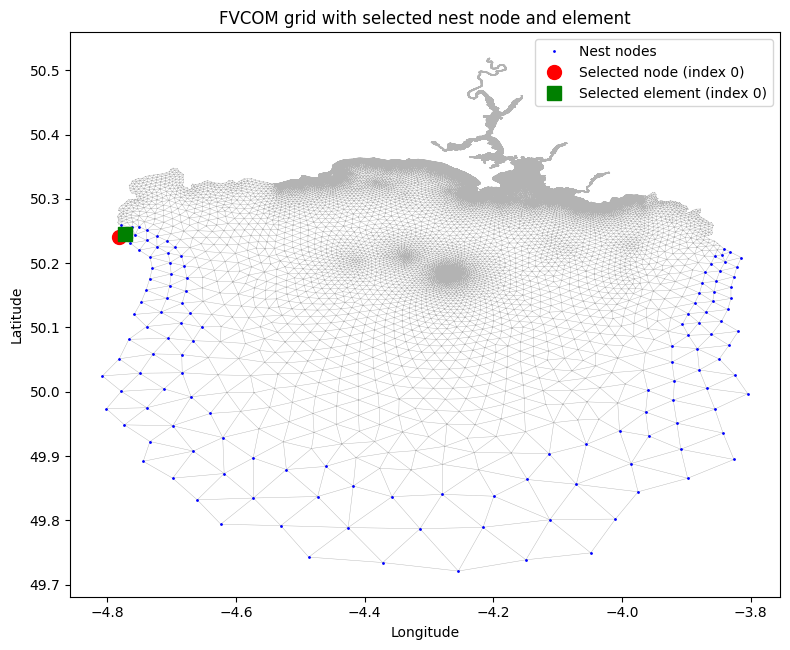

In [12]:
# --- Parameter: which nest node/element to plot ---
nest_index = 0

nest_node_indices = nest_atlas.get_all_nest_nodes()
nest_elem_indices = nest_atlas.get_all_nest_elements()
node_lon = fvcom_grid.lon_nodes[nest_node_indices[nest_index]]
node_lat = fvcom_grid.lat_nodes[nest_node_indices[nest_index]]
elem_lon = fvcom_grid.lonc[nest_elem_indices[nest_index]]
elem_lat = fvcom_grid.latc[nest_elem_indices[nest_index]]
print(f'Nest index: {nest_index}')
print(f'Node location: lon={node_lon:.4f}, lat={node_lat:.4f}')
print(f'Element location: lon={elem_lon:.4f}, lat={elem_lat:.4f}')

fig, ax = plt.subplots(figsize=(8, 8))
ax.triplot(fvcom_grid.lon_nodes, fvcom_grid.lat_nodes,
           fvcom_grid.triangles, linewidth=0.3, color='0.7')
ax.plot(fvcom_grid.lon_nodes[nest_node_indices],
        fvcom_grid.lat_nodes[nest_node_indices],
        'b.', markersize=2, label='Nest nodes')
ax.plot(node_lon, node_lat, 'ro', markersize=10, zorder=5,
        label=f'Selected node (index {nest_index})')
ax.plot(elem_lon, elem_lat, 'gs', markersize=10, zorder=5,
        label=f'Selected element (index {nest_index})')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('FVCOM grid with selected nest node and element')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 8. Compare SSH (Zeta)

Compare the tide-adjusted SSH time series at the selected nest node using
Atlas vs coarse TPXO tidal harmonics. Also show the tidal components alone
and their difference.

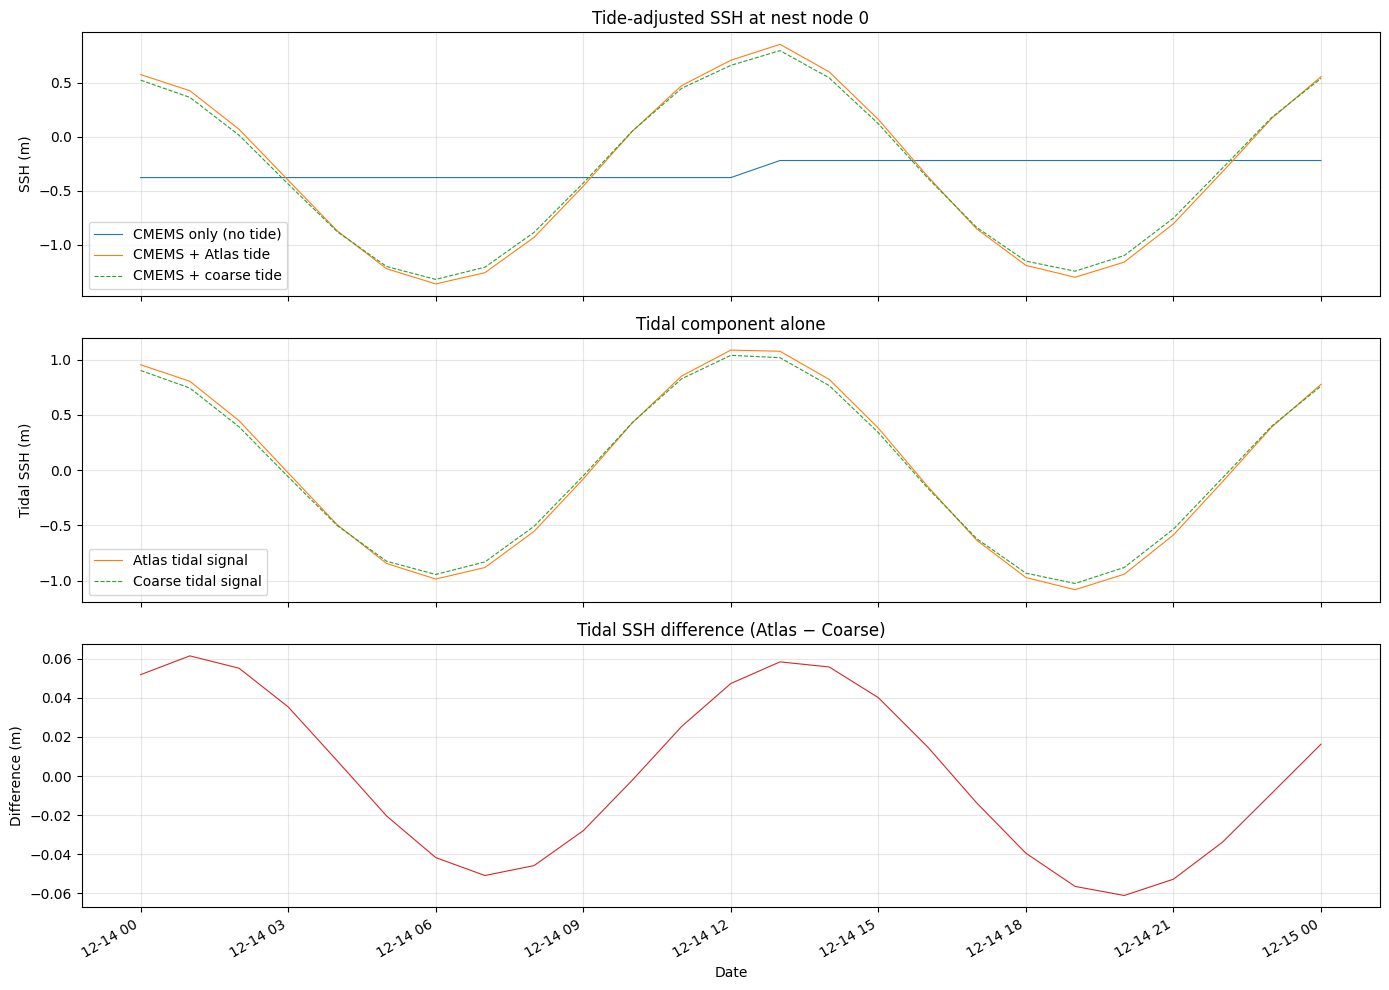

Max absolute tidal SSH difference: 0.0614 m
RMS tidal SSH difference: 0.0413 m


In [13]:
# Extract zeta data
zeta_cmems = nest_atlas.get_forcing_data('zeta', adjust_tides=False)[:, nest_index]
zeta_atlas = nest_atlas.get_forcing_data('zeta', adjust_tides=True)[:, nest_index]
zeta_coarse = nest_coarse.get_forcing_data('zeta', adjust_tides=True)[:, nest_index]
zeta_tidal_atlas = nest_atlas.get_tidal_data('zeta')[:, nest_index]
zeta_tidal_coarse = nest_coarse.get_tidal_data('zeta')[:, nest_index]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: tide-adjusted SSH
axes[0].plot(date_times, zeta_cmems, label='CMEMS only (no tide)', linewidth=0.8, color='C0')
axes[0].plot(date_times, zeta_atlas, label='CMEMS + Atlas tide', linewidth=0.8, color='C1')
axes[0].plot(date_times, zeta_coarse, label='CMEMS + coarse tide', linewidth=0.8, color='C2', linestyle='--')
axes[0].set_ylabel('SSH (m)')
axes[0].set_title(f'Tide-adjusted SSH at nest node {nest_index}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: tidal component only
axes[1].plot(date_times, zeta_tidal_atlas, label='Atlas tidal signal', linewidth=0.8, color='C1')
axes[1].plot(date_times, zeta_tidal_coarse, label='Coarse tidal signal', linewidth=0.8, color='C2', linestyle='--')
axes[1].set_ylabel('Tidal SSH (m)')
axes[1].set_title('Tidal component alone')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: difference
axes[2].plot(date_times, zeta_tidal_atlas - zeta_tidal_coarse, color='C3', linewidth=0.8)
axes[2].set_ylabel('Difference (m)')
axes[2].set_xlabel('Date')
axes[2].set_title('Tidal SSH difference (Atlas \u2212 Coarse)')
axes[2].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f'Max absolute tidal SSH difference: {np.max(np.abs(zeta_tidal_atlas - zeta_tidal_coarse)):.4f} m')
print(f'RMS tidal SSH difference: {np.sqrt(np.mean((zeta_tidal_atlas - zeta_tidal_coarse)**2)):.4f} m')

## 9. Compare Surface Velocities (u, v)

Compare tide-adjusted surface u and v velocities at the selected nest element.

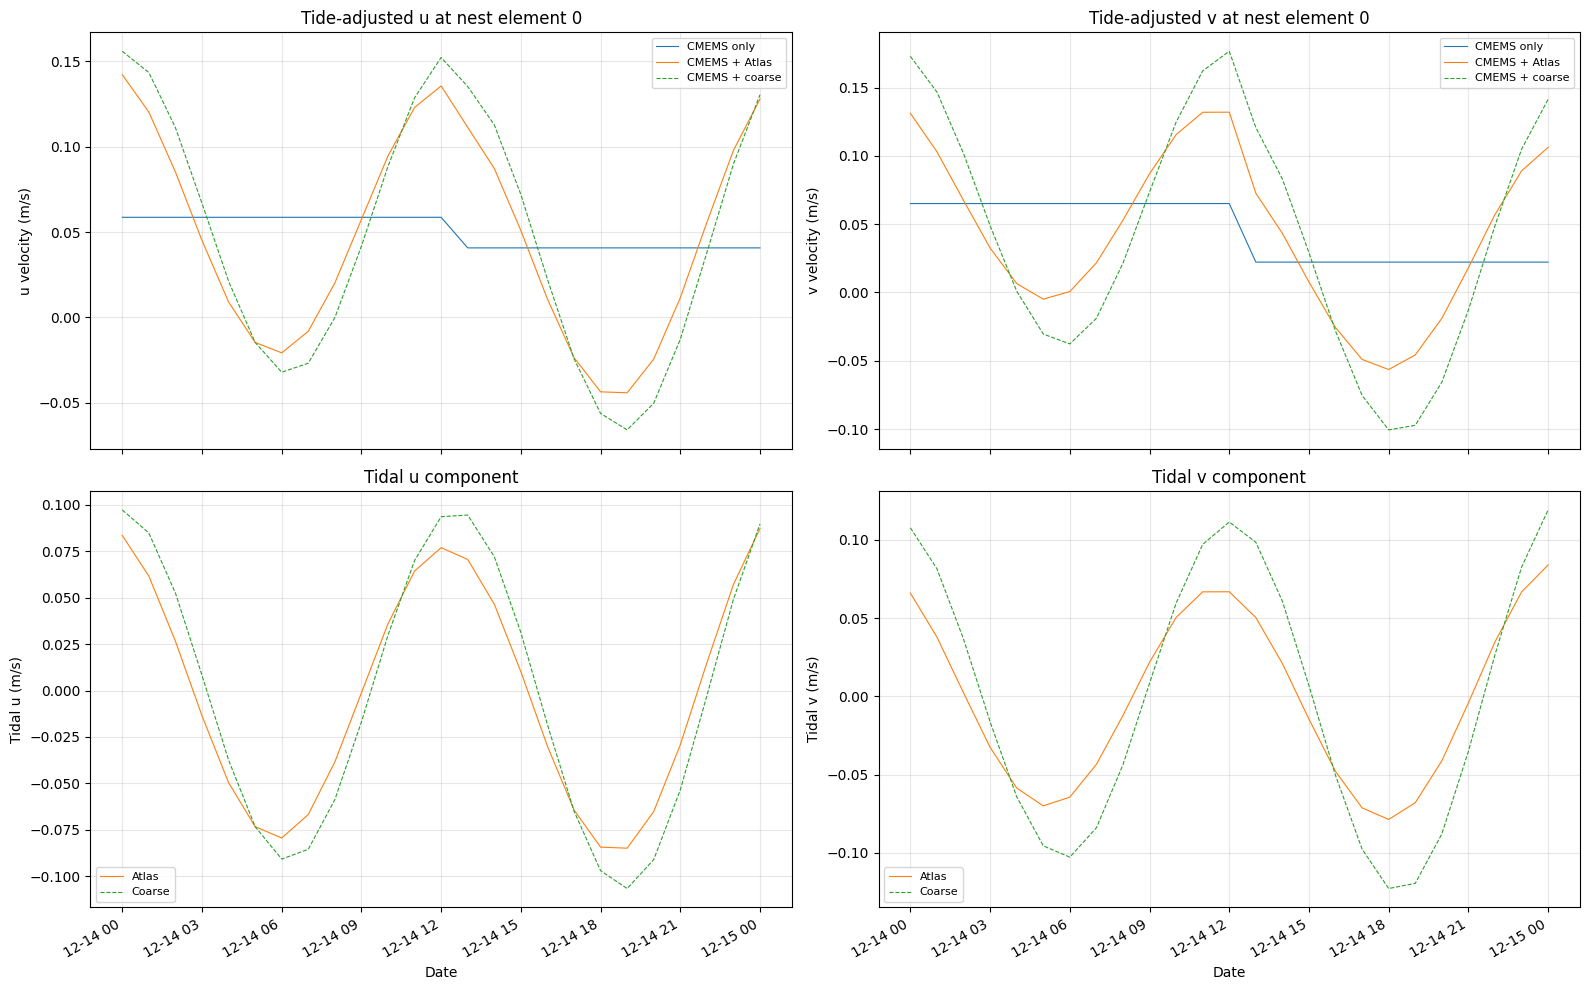

In [14]:
# Extract velocity data (surface layer = index 0)
u_cmems = nest_atlas.get_forcing_data('u', adjust_tides=False)[:, 0, nest_index]
u_atlas = nest_atlas.get_forcing_data('u', adjust_tides=True)[:, 0, nest_index]
u_coarse = nest_coarse.get_forcing_data('u', adjust_tides=True)[:, 0, nest_index]
u_tidal_atlas = nest_atlas.get_tidal_data('u')[:, nest_index]
u_tidal_coarse = nest_coarse.get_tidal_data('u')[:, nest_index]

v_cmems = nest_atlas.get_forcing_data('v', adjust_tides=False)[:, 0, nest_index]
v_atlas = nest_atlas.get_forcing_data('v', adjust_tides=True)[:, 0, nest_index]
v_coarse = nest_coarse.get_forcing_data('v', adjust_tides=True)[:, 0, nest_index]
v_tidal_atlas = nest_atlas.get_tidal_data('v')[:, nest_index]
v_tidal_coarse = nest_coarse.get_tidal_data('v')[:, nest_index]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# Top left: u-velocity tide-adjusted
axes[0, 0].plot(date_times, u_cmems, label='CMEMS only', linewidth=0.8, color='C0')
axes[0, 0].plot(date_times, u_atlas, label='CMEMS + Atlas', linewidth=0.8, color='C1')
axes[0, 0].plot(date_times, u_coarse, label='CMEMS + coarse', linewidth=0.8, color='C2', linestyle='--')
axes[0, 0].set_ylabel('u velocity (m/s)')
axes[0, 0].set_title(f'Tide-adjusted u at nest element {nest_index}')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Top right: v-velocity tide-adjusted
axes[0, 1].plot(date_times, v_cmems, label='CMEMS only', linewidth=0.8, color='C0')
axes[0, 1].plot(date_times, v_atlas, label='CMEMS + Atlas', linewidth=0.8, color='C1')
axes[0, 1].plot(date_times, v_coarse, label='CMEMS + coarse', linewidth=0.8, color='C2', linestyle='--')
axes[0, 1].set_ylabel('v velocity (m/s)')
axes[0, 1].set_title(f'Tide-adjusted v at nest element {nest_index}')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Bottom left: u tidal component comparison
axes[1, 0].plot(date_times, u_tidal_atlas, label='Atlas', linewidth=0.8, color='C1')
axes[1, 0].plot(date_times, u_tidal_coarse, label='Coarse', linewidth=0.8, color='C2', linestyle='--')
axes[1, 0].set_ylabel('Tidal u (m/s)')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_title('Tidal u component')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Bottom right: v tidal component comparison
axes[1, 1].plot(date_times, v_tidal_atlas, label='Atlas', linewidth=0.8, color='C1')
axes[1, 1].plot(date_times, v_tidal_coarse, label='Coarse', linewidth=0.8, color='C2', linestyle='--')
axes[1, 1].set_ylabel('Tidal v (m/s)')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_title('Tidal v component')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 10. Velocity Differences

Plot the difference in tidal u and v between Atlas and coarse, along with
summary statistics.

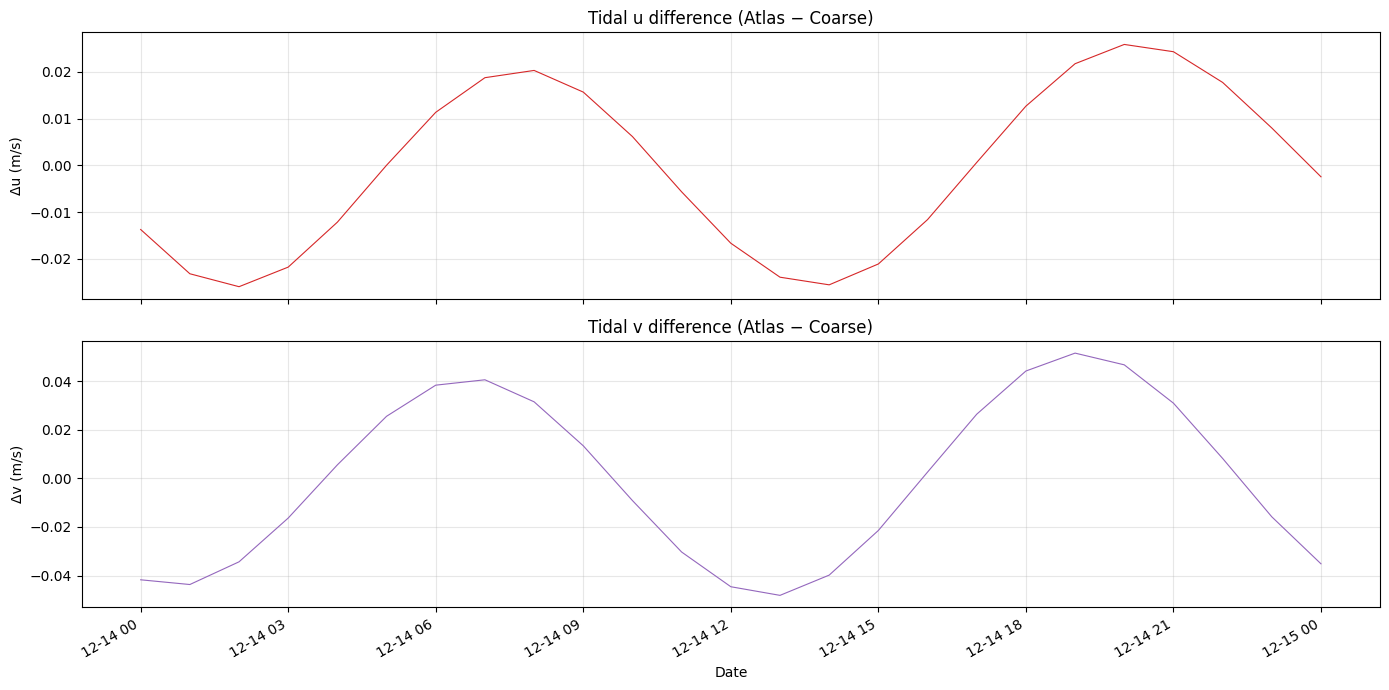

Tidal u: max |diff| = 0.0260 m/s, RMS = 0.0174 m/s
Tidal v: max |diff| = 0.0515 m/s, RMS = 0.0331 m/s


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

u_diff = u_tidal_atlas - u_tidal_coarse
v_diff = v_tidal_atlas - v_tidal_coarse

axes[0].plot(date_times, u_diff, color='C3', linewidth=0.8)
axes[0].set_ylabel('\u0394u (m/s)')
axes[0].set_title('Tidal u difference (Atlas \u2212 Coarse)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(date_times, v_diff, color='C4', linewidth=0.8)
axes[1].set_ylabel('\u0394v (m/s)')
axes[1].set_xlabel('Date')
axes[1].set_title('Tidal v difference (Atlas \u2212 Coarse)')
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f'Tidal u: max |diff| = {np.max(np.abs(u_diff)):.4f} m/s, RMS = {np.sqrt(np.mean(u_diff**2)):.4f} m/s')
print(f'Tidal v: max |diff| = {np.max(np.abs(v_diff)):.4f} m/s, RMS = {np.sqrt(np.mean(v_diff**2)):.4f} m/s')